# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

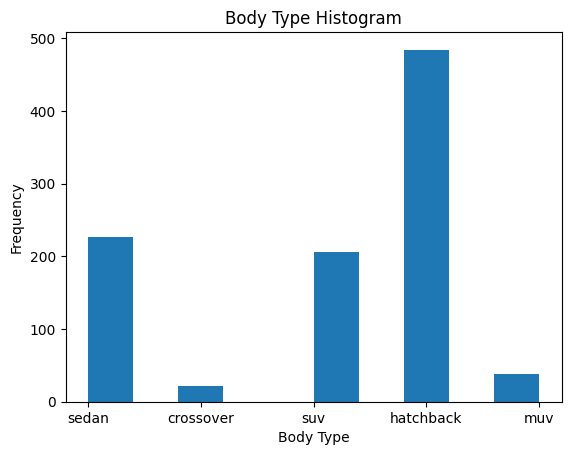

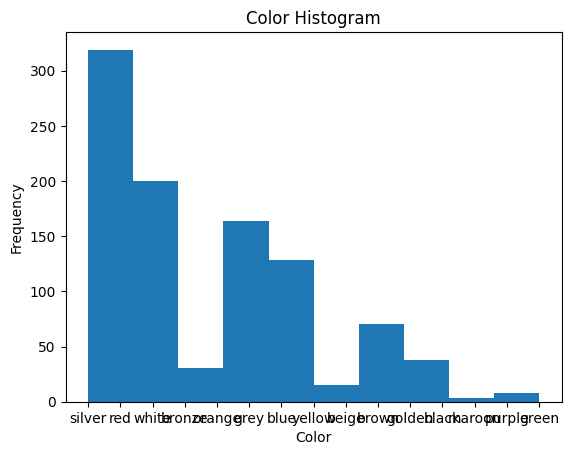

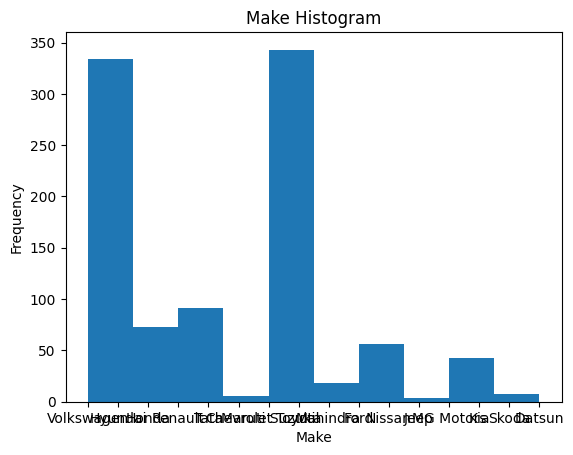

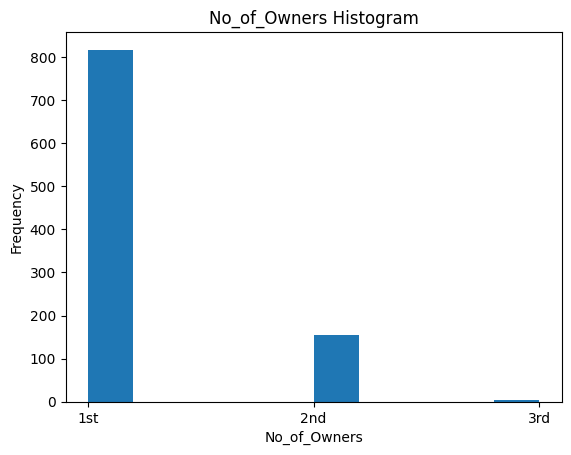

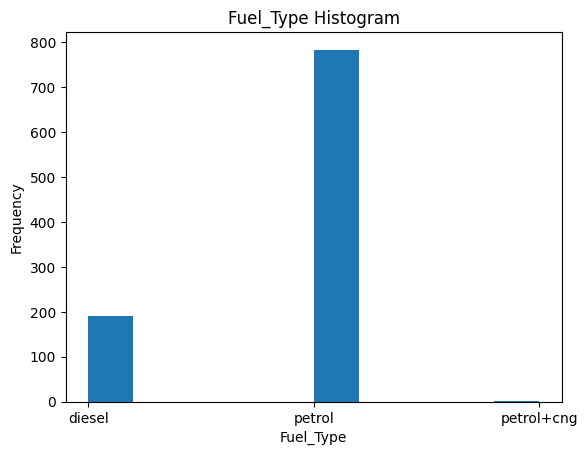

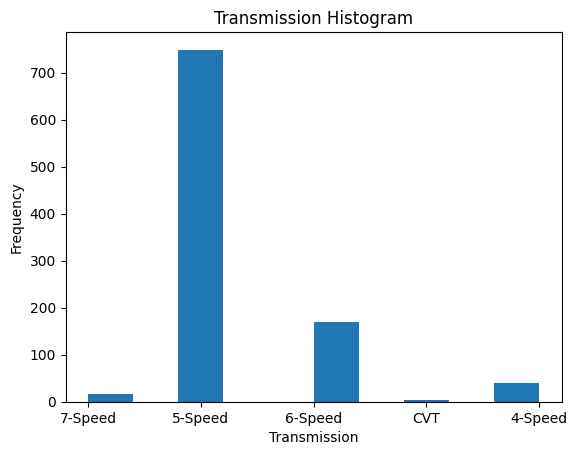

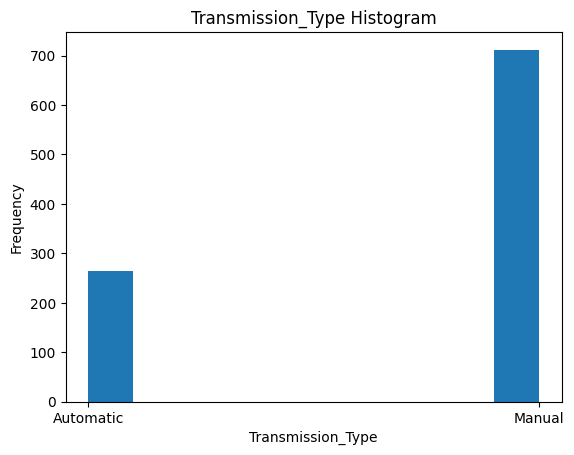

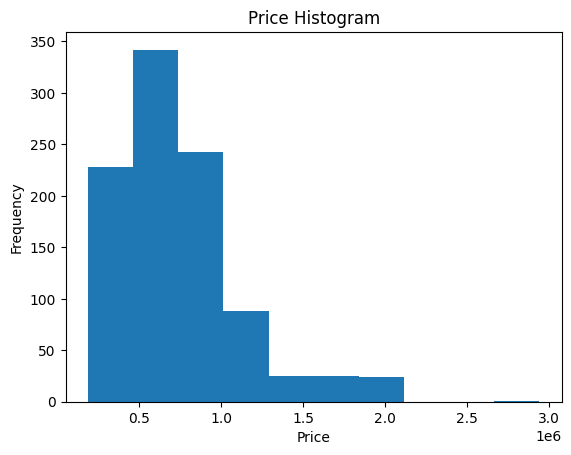

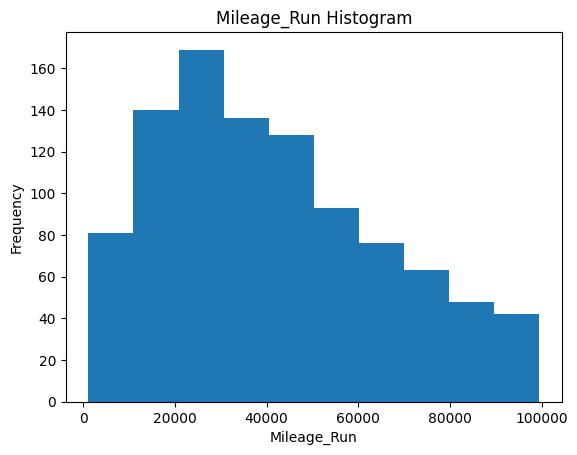

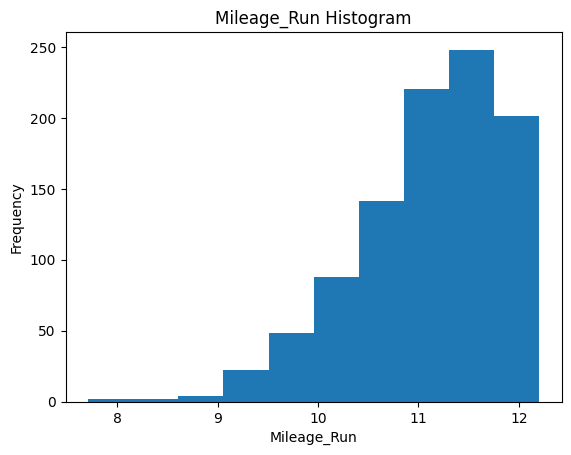

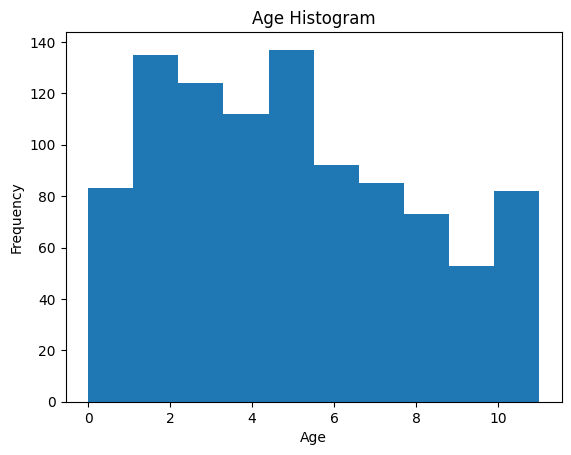

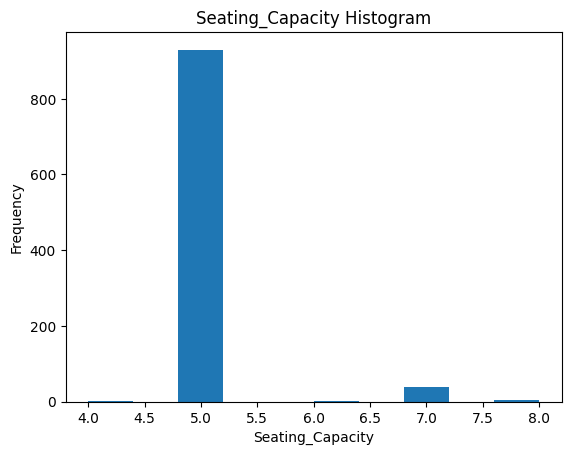

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

#1
data = pd.read_csv("/data/cars_hw.csv")
data['age'] = max(data['Make_Year']) - data['Make_Year']

plt.hist(x = data['Body_Type'])
plt.title('Body Type Histogram')
plt.xlabel('Body Type')
plt.ylabel('Frequency')
plt.show()

plt.hist(x = data['Color'])
plt.title('Color Histogram')
plt.xlabel('Color')
plt.ylabel('Frequency')
plt.show()

plt.hist(x = data['Make'])
plt.title('Make Histogram')
plt.xlabel('Make')
plt.ylabel('Frequency')
plt.show()

plt.hist(x = data['No_of_Owners'])
plt.title('No_of_Owners Histogram')
plt.xlabel('No_of_Owners')
plt.ylabel('Frequency')
plt.show()

plt.hist(x = data['Fuel_Type'])
plt.title('Fuel_Type Histogram')
plt.xlabel('Fuel_Type')
plt.ylabel('Frequency')
plt.show()

plt.hist(x = data['Transmission'])
plt.title('Transmission Histogram')
plt.xlabel('Transmission')
plt.ylabel('Frequency')
plt.show()

plt.hist(x = data['Transmission_Type'])
plt.title('Transmission_Type Histogram')
plt.xlabel('Transmission_Type')
plt.ylabel('Frequency')
plt.show()

plt.hist(data['Price'])
plt.title('Price Histogram')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

plt.hist(data['Mileage_Run'])
plt.title('Mileage_Run Histogram')
plt.xlabel('Mileage_Run')
plt.ylabel('Frequency')
plt.show()

plt.hist(np.arcsinh(data['Mileage_Run']))
plt.title('Mileage_Run Histogram')
plt.xlabel('Mileage_Run')
plt.ylabel('Frequency')
plt.show()

plt.hist(data['age'])
plt.title('Age Histogram')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

plt.hist(data['Seating_Capacity'])
plt.title('Seating_Capacity Histogram')
plt.xlabel('Seating_Capacity')
plt.ylabel('Frequency')
plt.show()

#2
data = pd.get_dummies(data, columns = ['Body_Type', 'Color', 'Make', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type'], drop_first = True)
X = data.drop(columns = ['Price', 'Unnamed: 0', 'Make_Year'])
y = data['Price']

#3
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 6)

In [130]:
#4
X_mile_train = X_train[['Mileage_Run']]
X_mile_test = X_test[['Mileage_Run']]
model_mile = LinearRegression().fit(X_mile_train, y_train)
print('Mile Model: \nR-squared: ', model_mile.score(X_mile_test, y_test))
print('RMSE: ', np.sqrt(np.mean((model_mile.predict(X_mile_test) - y_test)**2)), '\n')

X_age_train = X_train[['age']]
X_age_test = X_test[['age']]
model_age = LinearRegression().fit(X_age_train, y_train)
print('Age Model: \nR-squared: ', model_age.score(X_age_test, y_test))
print('RMSE: ', np.sqrt(np.mean((model_age.predict(X_age_test) - y_test)**2)), '\n')

X_seats_train = X_train[['Seating_Capacity']]
X_seats_test = X_test[['Seating_Capacity']]
model_seats = LinearRegression().fit(X_seats_train, y_train)
print('Seat Capacity Model: \nR-squared: ', model_seats.score(X_seats_test, y_test))
print('RMSE: ', np.sqrt(np.mean((model_seats.predict(X_seats_test) - y_test)**2)))

print('Model based on age does best, but not good with the only positive R-squared, albeit at 0.27')

Mile Model: 
R-squared:  -0.011313957308529021
RMSE:  329814.29519093485 

Age Model: 
R-squared:  0.2750304878915085
RMSE:  279245.60492917855 

Seat Capacity Model: 
R-squared:  -0.0012404786965705128
RMSE:  328167.5800156511
Model based on age does best, but not good with the only positive R-squared, albeit at 0.27


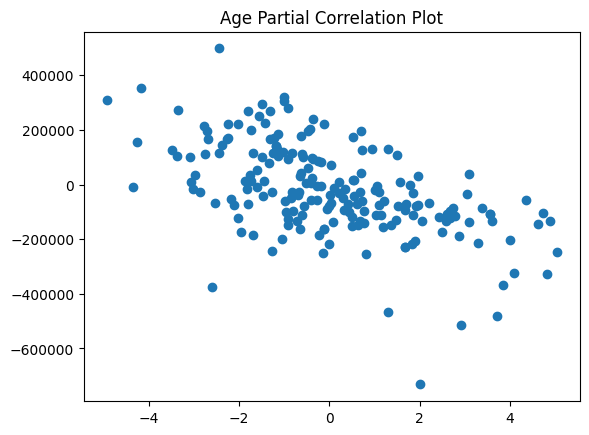

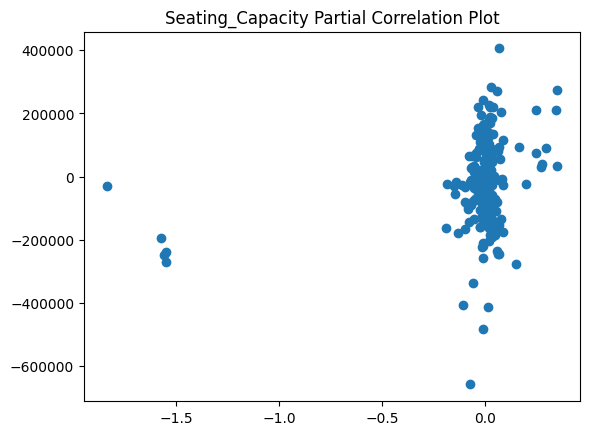

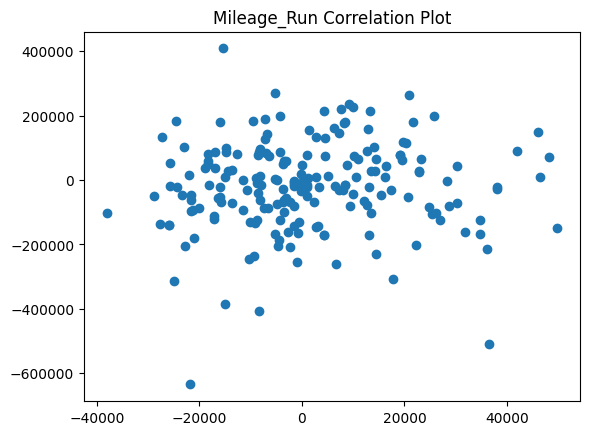

The age plot is slightly curved, and the Mileage_run is very spread out.


In [102]:
#5
age_out_train = X_train.drop('age', axis = 1)
age_out_test = X_test.drop('age', axis = 1)
age_train = X_train['age']
age_test = X_test['age']
m_age_out = LinearRegression().fit(age_out_train, y_train)
age_out_res = y_test - m_age_out.predict(age_out_test)
m_age = LinearRegression().fit(age_out_train, age_train)
age_res = age_test - m_age.predict(age_out_test)
plt.scatter(age_res, age_out_res)
plt.title('Age Partial Correlation Plot')
plt.show()

seats_out_train = X_train.drop('Seating_Capacity', axis = 1)
seats_out_test = X_test.drop('Seating_Capacity', axis = 1)
seats_train = X_train['Seating_Capacity']
seats_test = X_test['Seating_Capacity']
m_seats_out = LinearRegression().fit(seats_out_train, y_train)
seats_out_res = y_test - m_seats_out.predict(seats_out_test)
m_seats = LinearRegression().fit(seats_out_train, seats_train)
seats_res = seats_test - m_seats.predict(seats_out_test)
plt.scatter(seats_res, seats_out_res)
plt.title('Seating_Capacity Partial Correlation Plot')
plt.show()

miles_out_train = X_train.drop('Mileage_Run', axis = 1)
miles_out_test = X_test.drop('Mileage_Run', axis = 1)
miles_train = X_train['Mileage_Run']
miles_test = X_test['Mileage_Run']
m_miles_out = LinearRegression().fit(miles_out_train, y_train)
miles_out_res = y_test - m_miles_out.predict(miles_out_test)
m_miles = LinearRegression().fit(miles_out_train, miles_train)
miles_res = miles_test - m_miles.predict(miles_out_test)
plt.scatter(miles_res, miles_out_res)
plt.title('Mileage_Run Correlation Plot')
plt.show()

print("The age plot is slightly curved, and the Mileage_run is very spread out.")

In [120]:
#6
model = LinearRegression().fit((X_train), y_train)
print('Complex Model with transformations: \nR-squared: ', model.score(X_test, y_test))
print('RMSE: ', np.sqrt(np.mean((model.predict(X_test) - y_test)**2)), '\n')

X_train_complex = X_train.drop(columns = ['Mileage_Run']) #drop mileage_run because of the weak relation
X_test_complex = X_test.drop(columns = ['Mileage_Run'])
X_train_complex['age'] = np.arcsinh(X_train_complex['age']) #transform age to account for non-linearity
X_test_complex['age'] = np.arcsinh(X_test_complex['age'])
model_complex = LinearRegression().fit((X_train_complex), y_train)
print('Complex-adjusted Model with transformations, age arcsinh transformed, and mileage_run dropped: \nR-squared: ', model_complex.score(X_test_complex, y_test))
print('RMSE: ', np.sqrt(np.mean((model_complex.predict(X_test_complex) - y_test)**2)))

Complex Model with transformations: 
R-squared:  0.8175900377299521
RMSE:  140071.81355558563 

Complex-adjusted Model with transformations, age arcsinh transformed, and mileage_run dropped: 
R-squared:  0.8209549540359846
RMSE:  138773.84752875302


#7
First, produced histograms of every variable, but didn't notice any significant issues. Added an age varibable that is the year of the newest make minus the year of make. Also added dummy variables. After that, the data was split into an 80/20 train/test split and simple models based on single numerical models were built with the one based on age performing best, but not really good at all. Then built partial correlation plots, which showed that age may be non-linear, miles is weakly correlated, and seating capacity is a strong predictor. Finally built a model that included the dummy encoded transformations and then one that also arcsinh transformed the age variable and dropped the mileage_run variable in accordance with the conclusions from the partial correlation plots. The second model performed slightly better.

It seems like including as many variables that are linearly correlated makes for the best model. The simple models were probably underfit as seen from their low r-squared values, while the initial complex model probably overfit since it included some variables that weren't exactly linearly correlated to the prediction variable.